#**TASK 1**: Understand and load Dataset


MNIST is a dataset containing 70k grayscale images of handwritten digits from 0-9 each being 28x28 pixels image file. Out of 70k images, 60 k is meant for training the model(the training set) and the remaining 10k is kept for testing the model(the testing set).

So each of these images are converted to tensors(an array of number typeshit so that the computer can interpret it) and each of the elements of the tensor array represents the value of some parameter say here Height,Width or Channel.So these images being grayscale images, the channel values indicate towards the greyness of the pixel(0 being completely black, 255 being completely white).

While performing compuatation with the Neural network using tensors such high values in channel can create issues while gradient descent or backpropogation. Hence we **normalize** each of the channel values to btwn 0-1 by dividing the values by 255(0-black;1-white) and then send it for training.

The required model will take input as an image of a handwritten number btwn 0-9 and predict what number is written on it and give the number predicted with highest probability as output.

(ALL OF THESE WERE NOT AI GENERATED BTW 🙏 and are selfwritten)

In [72]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

In [73]:
train_data=datasets.MNIST(root='data',train=True,download=True,transform=transforms.ToTensor())
test_data=datasets.MNIST(root='data',train=False,download=True,transform=transforms.ToTensor())
#ToTensor() transformation readily converts the images to normalized tensors with each val btwn 0-1
firstImage=train_data[0][0]
firstLabel=train_data[0][1]
print(f"Datatype of the tensor:{firstImage.dtype}")
print(f"Shape of the tensor:{firstImage.size()}")#[C,H,W]
print(f"The digit in the image is:{firstLabel}")

Datatype of the tensor:torch.float32
Shape of the tensor:torch.Size([1, 28, 28])
The digit in the image is:5


For visualising the data uisng matplotlib we need to convert the tensor format from [C,H,W](Pytorch format) to [H,W,C](Matplotlib format). So we can use permute() to rearrange or just use squeeeze() to remove C for teh grayscae image.For the sake of generalized approach, using permute:

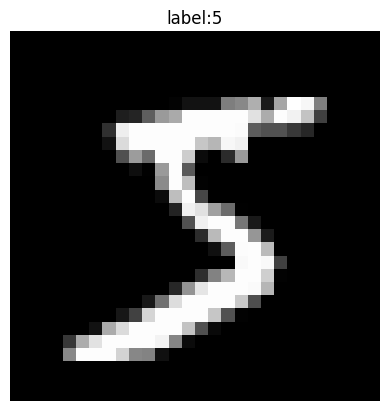

torch.float32 
 torch.Size([28, 28])


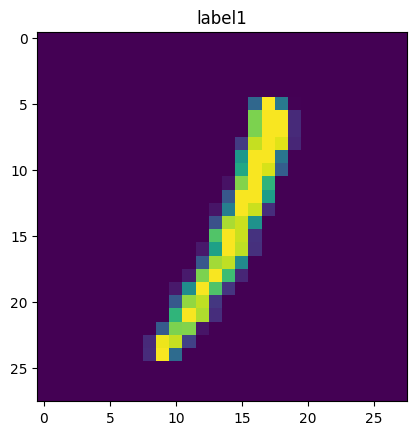

In [74]:
img1=firstImage.permute([1,2,0])
plt.imshow(img1,cmap="gray")
plt.title(f"label:{firstLabel}")
plt.axis("off")
plt.show()

img99=train_data[99][0].squeeze()
print(img99.dtype,"\n",img99.shape)
plt.imshow(img99)#without cmap=gray the image will be genrated in default purple green
plt.title(f"label{train_data[99][1]}")
plt.show()

# **Task2**: Setup Datapiepline

We have to setup a datapipeline for supplying data from the Daataset imported to the input of the ML model. There are certain things to be done before we feed it to the model for training known as data pre-processing. This includes converting the images into tensors(which we already did it during task 1) and normalize them (to ensure unbiased backprpogation and balanced weight allocation thus preventing underfitting).

DataLoader is used for feeding that data to input in batches which prevents data overload by large one-time input and slow processing by individual inputs.

The training data set is loaded as shuffled batches to prevent overfitting while it is not necessary for the test data to be shuffled as the model wont learn form test data.

torch.Size([64, 1, 28, 28])
torch.Size([64])
torch.Size([28, 28, 1])


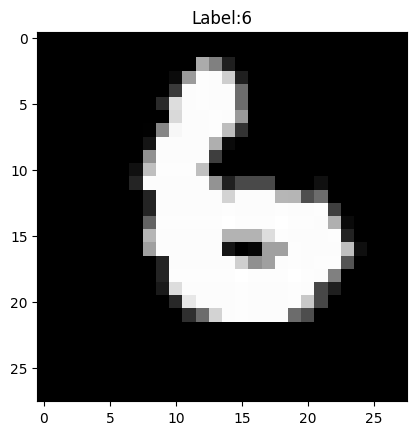

In [75]:
from numpy import degrees
#Transforming and Normalizing
train_data.transform=transforms.Compose([transforms.RandomAffine(degrees=10,shear=10),
                                         transforms.ToTensor(),
                                         transforms.Normalize((0.1307,),(0.3081,))])
#the most optimal Normalization constants for this dataset
test_data.transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.1307,),(0.3081,))])
#DataLoading
train_loader=DataLoader(dataset=train_data,batch_size=64,shuffle=True,num_workers=2,pin_memory=True)
test_loader=DataLoader(dataset=test_data,batch_size=64,shuffle=False,num_workers=2,pin_memory=True)

iterator=iter(train_loader)
img_set,label_set=next(iterator)
print(f"{img_set.shape}")#[Batch size,C,H,W]
print(f"{label_set.shape}")#[batch size]
sample_img=img_set[0].permute([1,2,0])
print(f"{sample_img.shape}")
plt.imshow(sample_img,cmap="gray")
plt.title(f"Label:{label_set[0]}")
plt.show()

#**Task3**- Deploy a NeuralNetwork



Convoultion layers are used to extract features from the input data. Filters are like the detectors for each feature panning over regions of the img.Kernel size is the size of the filter(say 3x3).Stride is the number of pixels the fiter moves each time.Padding is adding an additional layer of zeroes towards the boundaries to prevent loss of boundary details from actual image during feature mapping.

Pooling layers is when the height and widht of the image file is reducing based on the req(preferably half each time) to reduce the data load thru size as the number of features are increased.

Dropout is the random deactivation of a set of neurons in each cycle(say 25%)to prevent domination amongst neurons hence overfitting.

Fully connected linear layers are the final flattened tensors for after all the convolutions and pooling.They are the last steps towards converting the features analysed into prediction for the categories.

softmax is the function that converts the prediction scores for each logit into overall probability each lying btwn 0-1, net summing to 1.
log_softmax is the log of softmax which helps in not vanishing the gradient in case of very small probabilities.

In [76]:
class net(nn.Module):
  def __init__(self):
    super(net,self).__init__()

    self.con1=nn.Conv2d(1,4,3,1,1)
    self.bn1=nn.BatchNorm2d(4)
    self.con1b=nn.Conv2d(4,4,3,1,1)
    self.bn1b=nn.BatchNorm2d(4)
    self.pool1=nn.MaxPool2d(2,2)

    self.con2=nn.Conv2d(4,8,3,1,1)
    self.bn2=nn.BatchNorm2d(8)
    self.con2b=nn.Conv2d(8,8,3,1,1)
    self.bn2b=nn.BatchNorm2d(8)
    self.pool2=nn.MaxPool2d(2,2)

    self.con3=nn.Conv2d(8,16,3,1,1)
    self.bn3=nn.BatchNorm2d(16)
    self.con3b=nn.Conv2d(16,16,3,1,1)
    self.bn3b=nn.BatchNorm2d(16)

    self.con4=nn.Conv2d(16,32,3,1,1)
    self.bn4=nn.BatchNorm2d(32)
    self.con4b=nn.Conv2d(32,32,3,1,1)
    self.bn4b=nn.BatchNorm2d(32)

    self.poolfinal=nn.AdaptiveAvgPool2d((2,2))

    self.relu=nn.ReLU()
    self.drop=nn.Dropout2d(0.25)

    self.l1=nn.Linear(128,64)
    self.l2=nn.Linear(64,10)

  def forward(self,x):
    x=self.relu(self.bn1(self.con1(x)))
    x=self.pool1(x)

    x=self.relu(self.bn2(self.con2(x)))
    x=self.pool2(x)

    x=self.relu(self.bn3(self.con3(x)))

    x=self.relu(self.bn4(self.con4(x)))

    x=self.poolfinal(x)
    x=self.drop(x)

    x=x.view(-1,128)
    x=self.relu(self.l1(x))
    logits=self.l2(x)
    return F.log_softmax(logits,dim=1)

In [77]:
model=net()
criterion=nn.NLLLoss()
optimizer=optim.Adam(model.parameters(),lr=0.001)
scheduler=optim.lr_scheduler.StepLR(optimizer,step_size=8,gamma=0.1)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def train(model,device,train_loader,optimimzer):
  model.train()
  running_loss=0.0
  for batch_idx,(images,labels) in enumerate(train_loader):
    images,labels=images.to(device),labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()
    if batch_idx%100==0:
      print(f"Batch:{batch_idx}/{len(train_loader)} | Loss:{loss.item():.4f}")
  avg_epoch_loss=running_loss/len(train_loader)
  print(f"Epoch training done |  Avg loss:{avg_epoch_loss:.4f}")
  return avg_epoch_loss

train_losses=[]
for epoch in range(1,21):
  epoch_loss=train(model,device,train_loader,optimizer)
  train_losses.append(epoch_loss)
  scheduler.step()

Batch:0/938 | Loss:2.3339
Batch:100/938 | Loss:0.9283
Batch:200/938 | Loss:0.3541
Batch:300/938 | Loss:0.1898
Batch:400/938 | Loss:0.2698
Batch:500/938 | Loss:0.2053
Batch:600/938 | Loss:0.2557
Batch:700/938 | Loss:0.2420
Batch:800/938 | Loss:0.2383
Batch:900/938 | Loss:0.1631
Epoch training done |  Avg loss:0.4149
Batch:0/938 | Loss:0.1411
Batch:100/938 | Loss:0.1764
Batch:200/938 | Loss:0.0637
Batch:300/938 | Loss:0.1608
Batch:400/938 | Loss:0.2043
Batch:500/938 | Loss:0.0423
Batch:600/938 | Loss:0.0821
Batch:700/938 | Loss:0.2797
Batch:800/938 | Loss:0.1758
Batch:900/938 | Loss:0.0396
Epoch training done |  Avg loss:0.1343
Batch:0/938 | Loss:0.0344
Batch:100/938 | Loss:0.0552
Batch:200/938 | Loss:0.1080
Batch:300/938 | Loss:0.1968
Batch:400/938 | Loss:0.0872
Batch:500/938 | Loss:0.1331
Batch:600/938 | Loss:0.1019
Batch:700/938 | Loss:0.1290
Batch:800/938 | Loss:0.0909
Batch:900/938 | Loss:0.0923
Epoch training done |  Avg loss:0.1049
Batch:0/938 | Loss:0.1304
Batch:100/938 | Loss:0.

In [78]:
def evaluator(model,device,test_loader,criterion):
  model.eval()
  test_loss=0
  correct=0
  with torch.no_grad():
    for images,labels in test_loader:
      images, labels=images.to(device),labels.to(device)
      output=model(images)
      test_loss+=criterion(output,labels).item()
      predictions=output.argmax(dim=1,keepdim=True)
      correct+=predictions.eq(labels.view_as(predictions)).sum().item()
  avg_test_loss=test_loss/len(test_loader)
  test_accuracy=100*(correct/len(test_loader.dataset))

  print(f"Avg test loss:{avg_test_loss:.4f}")
  print(f"Overall Accuracy:{test_accuracy}")
  return avg_test_loss,test_accuracy

In [79]:
test_loss, test_accuracy= evaluator(model,device,test_loader,criterion)

Avg test loss:0.0237
Overall Accuracy:99.25


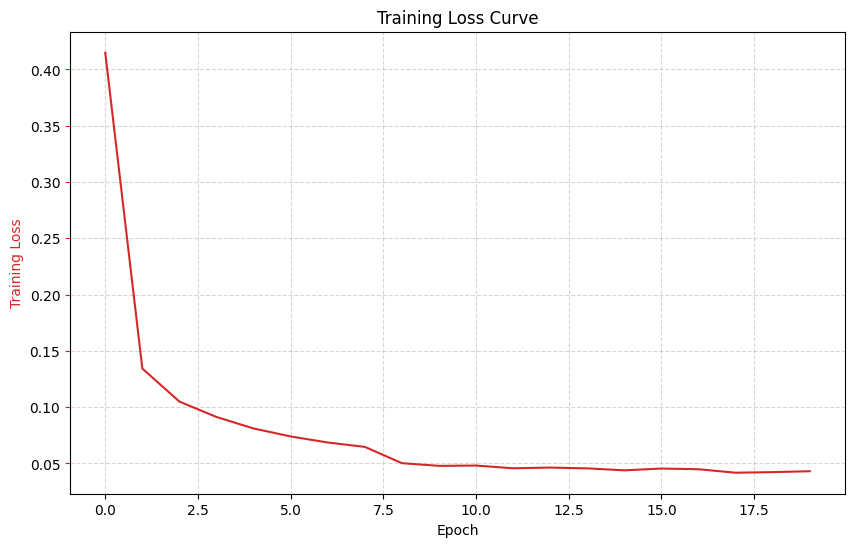

In [80]:
fig,ax1=plt.subplots(figsize=(10,6))

color='tab:red'
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss',color=color)
ax1.plot(train_losses,color=color)
ax1.tick_params(axis='y',color=color)
ax1.grid(True,linestyle='--',alpha=0.5)

plt.title("Training Loss Curve")
plt.show()

In [81]:
weights='mnist_digit_model.pth'
torch.save(model.state_dict(),weights)
print("success")

interference_model=net().to(device)
interference_model.load_state_dict(torch.load(weights,map_location=device))
interference_model.eval()
print("success")

test_image,true_label=test_data[0]
input_tensor=test_image.unsqueeze(0).to(device)

with torch.no_grad():
  log_prob=interference_model(input_tensor)
  prediction=log_prob.argmax(dim=1).item()

print(f"Ground Truth:{true_label}")
print(f"Predicted output:{prediction}")




success
success
Ground Truth:7
Predicted output:7
